In [4]:
import pandas as pd
from transformers import pipeline
from tqdm import tqdm

In [3]:
data_path = "/home/husted42/Downloads/European_data_2000.csv"

import pandas as pd
df = pd.read_csv(
    data_path,
    sep=",",
    engine="python",
    quotechar='"',
    on_bad_lines="skip"   
)

print("Columns in the dataset: ")
print(df.columns.tolist())




Columns in the dataset: 
['titleId', 'imdbUrl', 'originalTitle', 'titleType', 'releaseYear', 'runtimeMinutes', 'isAdult', 'imdbRating', 'numberOfVotes', 'allCountries', 'mainCountry', 'allLanguages', 'firstLanguage', 'englishTitle', 'topFiveActors', 'directors', 'writers', 'plotShort', 'plotMedium', 'plotLong', 'genres', 'keywords', 'production']


In [ ]:
# Load zero-shot classifier
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0  # remove if you don't have GPU
)

# Define categories you want
labels = [
    "viking movie",
    "gay romance",
    "christmas",
    "war movie",
    "coming of age",
    "political drama",
    "crime thriller"
]

def classify_plot(plot):
    if pd.isna(plot):
        return {label:0 for label in labels}

    result = classifier(plot, labels)
    print(result)

    scores = dict(zip(result["labels"], result["scores"]))

    # Convert to binary features
    return {label: int(scores[label] > 0.5) for label in labels}


tqdm.pandas()

features = df["plotLong"].progress_apply(classify_plot)
features_df = pd.DataFrame(features.tolist())

df = pd.concat([df, features_df], axis=1)

print(df.head())

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

100%|██████████| 2000/2000 [25:54<00:00,  1.29it/s]

     titleId                                imdbUrl  \
0  tt3042384  https://www.imdb.com/title/tt3042384/   
1  tt2486278  https://www.imdb.com/title/tt2486278/   
2  tt1361313  https://www.imdb.com/title/tt1361313/   
3  tt0222124  https://www.imdb.com/title/tt0222124/   
4  tt0421229  https://www.imdb.com/title/tt0421229/   

                                       originalTitle titleType  releaseYear  \
0                                                Ida     movie       2013.0   
1                                         Blood Shed     movie       2013.0   
2                                      The Extra Man     movie       2010.0   
3  Se tutte le donne del mondo... (Operazione Par...     movie       1966.0   
4                       Mrs Palfrey at the Claremont     movie       2005.0   

   runtimeMinutes  isAdult  imdbRating  numberOfVotes    allCountries  ...  \
0            82.0    False         7.4        61189.0  PL, DK, FR, GB  ...   
1            99.0    False         3.1

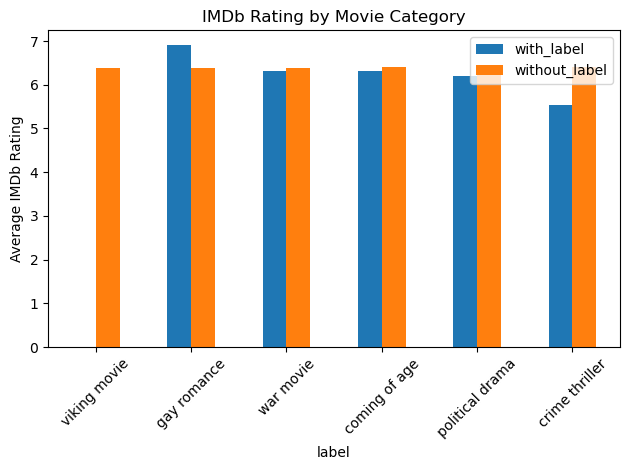

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

results = []

for label in labels:
    mean_with = df[df[label] == 1]["imdbRating"].mean()
    mean_without = df[df[label] == 0]["imdbRating"].mean()

    results.append({
        "label": label,
        "with_label": mean_with,
        "without_label": mean_without
    })

results_df = pd.DataFrame(results)

# Plot
results_df.set_index("label").plot(kind="bar")

plt.ylabel("Average IMDb Rating")
plt.title("IMDb Rating by Movie Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

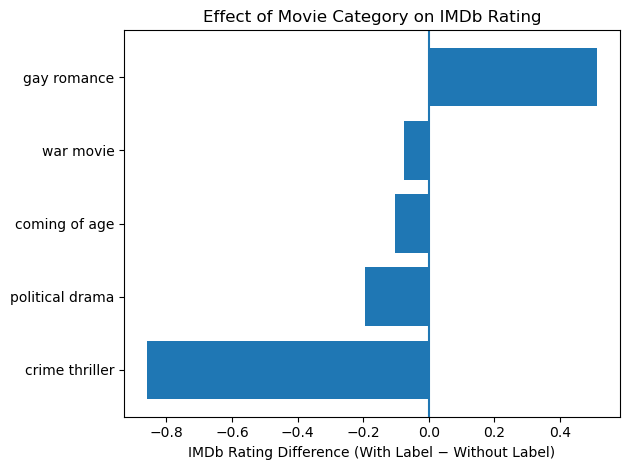

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

results = []

for label in labels:
    mean_with = df[df[label] == 1]["imdbRating"].mean()
    mean_without = df[df[label] == 0]["imdbRating"].mean()

    diff = mean_with - mean_without

    results.append({
        "label": label,
        "difference": diff
    })

results_df = pd.DataFrame(results)

# Sort so the plot is easier to read
results_df = results_df.sort_values("difference")

# Plot
plt.figure()

plt.barh(results_df["label"], results_df["difference"])

plt.xlabel("IMDb Rating Difference (With Label − Without Label)")
plt.title("Effect of Movie Category on IMDb Rating")

plt.axvline(0)  # reference line
plt.tight_layout()

plt.show()

In [10]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

results = []

for label in labels:

    group_with = df[df[label] == 1]["imdbRating"].dropna()
    group_without = df[df[label] == 0]["imdbRating"].dropna()

    mean_with = group_with.mean()
    mean_without = group_without.mean()

    diff = mean_with - mean_without

    # Welch t-test (safer when variances differ)
    t_stat, p_value = ttest_ind(group_with, group_without, equal_var=False)

    results.append({
        "label": label,
        "difference": diff,
        "p_value": p_value,
        "n_with": len(group_with),
        "n_without": len(group_without)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("difference")

print(results_df)

             label  difference   p_value  n_with  n_without
5   crime thriller   -0.860000  0.003163      20       1980
4  political drama   -0.195909  0.514280      12       1988
3    coming of age   -0.104001  0.092446     409       1591
2        war movie   -0.075629  0.826040       9       1991
1      gay romance    0.514114  0.106449       2       1998
0     viking movie         NaN       NaN       0       2000


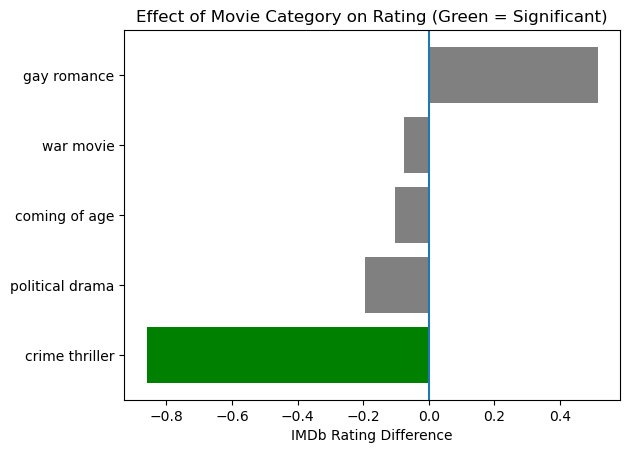

In [11]:
plt.figure()

colors = ["green" if p < 0.05 else "gray" for p in results_df["p_value"]]

plt.barh(results_df["label"], results_df["difference"], color=colors)

plt.axvline(0)
plt.xlabel("IMDb Rating Difference")
plt.title("Effect of Movie Category on Rating (Green = Significant)")

plt.show()

# Plot the embeddings

In [6]:
import pandas as pd
from transformers import pipeline
from tqdm import tqdm

df_short = df.head(20)  # for testing, use a smaller subset

# Load zero-shot classifier
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0  # remove if you don't have GPU
)

# Define categories you want
labels = [
    "political drama",
    "crime thriller"
]

def classify_plot(plot):
    if pd.isna(plot):
        return {label:0 for label in labels}

    result = classifier(plot, labels)

    scores = dict(zip(result["labels"], result["scores"]))
    print(scores)

    # Convert to binary features
    return {label: int(scores[label] > 0.5) for label in labels}


tqdm.pandas()

features = df_short["plotLong"].progress_apply(classify_plot)
features_df = pd.DataFrame(features.tolist())

df_short = pd.concat([df_short, features_df], axis=1)

print(df_short.head())

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

  2%|▏         | 2/100 [00:00<00:15,  6.19it/s]

{'political drama': 0.5994490385055542, 'crime thriller': 0.4005509614944458}
{'crime thriller': 0.6357160806655884, 'political drama': 0.36428382992744446}


  5%|▌         | 5/100 [00:00<00:15,  6.21it/s]

{'crime thriller': 0.6411996483802795, 'political drama': 0.3588002920150757}
{'political drama': 0.6304081678390503, 'crime thriller': 0.3695918321609497}


...

{'crime thriller': 0.6718945503234863, 'political drama': 0.32810547947883606}
{'crime thriller': 0.5531601309776306, 'political drama': 0.446839839220047}
{'political drama': 0.6880585551261902, 'crime thriller': 0.3119414150714874}


 99%|█████████▉| 99/100 [00:24<00:00,  4.46it/s]

{'political drama': 0.6026396751403809, 'crime thriller': 0.39736032485961914}


100%|██████████| 100/100 [00:24<00:00,  4.03it/s]

{'crime thriller': 0.5392645001411438, 'political drama': 0.4607354998588562}
{'crime thriller': 0.6285492181777954, 'political drama': 0.371450811624527}
     titleId                                imdbUrl  \
0  tt3042384  https://www.imdb.com/title/tt3042384/   
1  tt2486278  https://www.imdb.com/title/tt2486278/   
2  tt1361313  https://www.imdb.com/title/tt1361313/   
3  tt0222124  https://www.imdb.com/title/tt0222124/   
4  tt0421229  https://www.imdb.com/title/tt0421229/   

                                       originalTitle titleType  releaseYear  \
0                                                Ida     movie       2013.0   
1                                         Blood Shed     movie       2013.0   
2                                      The Extra Man     movie       2010.0   
3  Se tutte le donne del mondo... (Operazione Par...     movie       1966.0   
4                       Mrs Palfrey at the Claremont     movie       2005.0   

   runtimeMinutes  isAdult  imdbRating 